## WHACS vs ECAN Buoy Storm Validation


### Objective

The objective of this analysis is to evaluate the performance of the WHACS wave hindcast by comparing storm-related wave characteristics against observed data from the ECAN wave buoy.  
Specifically, this validation focuses on assessing how well WHACS reproduces observed storm wave heights and directional characteristics at a monthly scale during storm conditions.


In [ ]:
#import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Load data
whacs = pd.read_csv("WHACS_monthly_storm_metrics_with_dir.csv")
ecan  = pd.read_csv("ECAN_buoy_monthly_storm_metrics.csv")

print("WHACS columns:")
print(whacs.columns)

print("\nECAN columns:")
print(ecan.columns)



WHACS columns:
Index(['month', 'whacs_storm_count', 'whacs_mean_peak_Hs', 'whacs_max_peak_Hs',
       'whacs_mean_dir'],
      dtype='object')

ECAN columns:
Index(['month', 'ecan_storm_hours', 'ecan_max_Hs', 'ecan_mean_Hs',
       'ecan_mean_dir'],
      dtype='object')


In [26]:
whacs = pd.read_csv("WHACS_monthly_storm_metrics_with_dir.csv")



# Make sure month is datetime first (you already did this)
whacs["month"] = pd.to_datetime(whacs["month"], errors="coerce")

# Convert to string format: YYYY-DD-MM
whacs["month_str"] = whacs["month"].dt.strftime("%Y-%d-%m")

# Quick check
whacs[["month", "month_str"]].head()




,month,month_str
0,1999-01-01,1999-01-01
1,1999-02-01,1999-01-02
2,1999-03-01,1999-01-03
3,1999-04-01,1999-01-04
4,1999-05-01,1999-01-05


In [28]:
# Keep both columns, but we will merge on month_str
whacs_out = whacs.copy()

whacs_out.to_csv(
    "WHACS_monthly_storm_metrics_with_dir_for_merge.csv",
    index=False
)

print("Saved WHACS dataset with month_str for merging")


Saved WHACS dataset with month_str for merging


In [29]:
master = pd.read_csv("master_with_storm_types.csv")

master.head()
master.dtypes


month                     object
mean_shoreline_change    float64
ecan_storm_hours         float64
ecan_max_Hs              float64
ecan_mean_Hs             float64
ecan_mean_dir            float64
model_storm_hours        float64
model_max_Hs             float64
model_mean_Hs            float64
model_mean_dir           float64
erosion_month               bool
storm_type                 int64
dtype: object

In [31]:
master = master.rename(columns={"month": "month_str"})
merged = master.merge(
    whacs_out,
    on="month_str",
    how="left"
)

merged.head()


,month_str,mean_shoreline_change,ecan_storm_hours,ecan_max_Hs,ecan_mean_Hs,ecan_mean_dir,model_storm_hours,model_max_Hs,model_mean_Hs,model_mean_dir,erosion_month,storm_type,month,whacs_storm_count,whacs_mean_peak_Hs,whacs_max_peak_Hs,whacs_mean_dir
0,1999-01-07,NaN,10.0,3.22,2.694000,150.844000,20.0,6.1611,4.835027,148.519700,False,1,1999-07-01,5.0,4.487600,6.812,153.004590
1,1999-01-08,2.105517,7.0,3.60,3.117143,177.682857,2.0,4.4776,4.375580,195.086000,False,2,1999-08-01,6.0,4.098000,6.500,129.658826
2,1999-01-09,3.266016,2.0,3.62,3.160000,161.105000,7.0,4.5849,4.377566,197.312429,False,2,1999-09-01,12.0,3.395000,5.302,136.305946
3,1999-01-10,3.780714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1999-10-01,10.0,3.405600,4.918,154.125454
4,1999-01-11,1.193659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1999-11-01,6.0,4.128667,5.612,116.221587


In [32]:
# Summary of merged data
print("Merged rows:", len(merged))
print("\nMissing values per column:")
print(merged.isna().sum())


Merged rows: 314

Missing values per column:
month_str                  0
mean_shoreline_change      1
ecan_storm_hours          14
ecan_max_Hs               14
ecan_mean_Hs              14
ecan_mean_dir             14
model_storm_hours        131
model_max_Hs             131
model_mean_Hs            131
model_mean_dir           131
erosion_month              0
storm_type                 0
month                     23
whacs_storm_count         23
whacs_mean_peak_Hs        23
whacs_max_peak_Hs         23
whacs_mean_dir            23
dtype: int64


#### HS Comparision

In [6]:
# Differences
diff = merged["whacs_mean_peak_Hs"] - merged["ecan_mean_Hs"]

bias = diff.mean()
rmse = np.sqrt(np.mean(diff**2))
corr = np.corrcoef(
    merged["whacs_mean_peak_Hs"],
    merged["ecan_mean_Hs"]
)[0, 1]

print(f"Bias (WHACS − Buoy): {bias:.2f} m")
print(f"RMSE: {rmse:.2f} m")
print(f"Correlation (r): {corr:.2f}")

Bias (WHACS − Buoy): 1.30 m
RMSE: 1.47 m
Correlation (r): 0.11


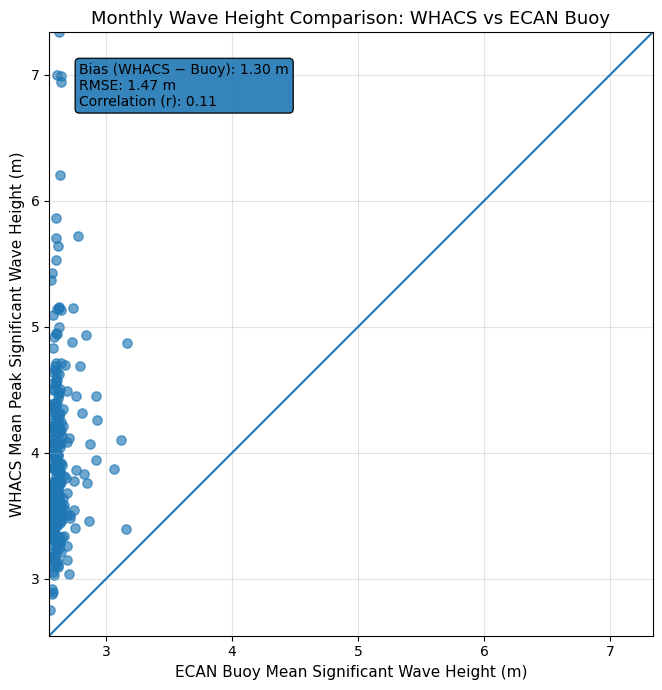

In [ ]:
# Compute validation statistics 
diff = merged["whacs_mean_peak_Hs"] - merged["ecan_mean_Hs"]
bias = diff.mean()
rmse = np.sqrt(np.mean(diff**2))
corr = np.corrcoef(
    merged["whacs_mean_peak_Hs"],
    merged["ecan_mean_Hs"]
)[0, 1]

# Plot 
plt.figure(figsize=(7, 7))

# Scatter points
plt.scatter(
    merged["ecan_mean_Hs"],
    merged["whacs_mean_peak_Hs"],
    alpha=0.65,
    s=45
)

# 1:1 line
lims = [
    min(merged["ecan_mean_Hs"].min(), merged["whacs_mean_peak_Hs"].min()),
    max(merged["ecan_mean_Hs"].max(), merged["whacs_mean_peak_Hs"].max())
]
plt.plot(lims, lims)

# Axis formatting
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("ECAN Buoy Mean Significant Wave Height (m)", fontsize=11)
plt.ylabel("WHACS Mean Peak Significant Wave Height (m)", fontsize=11)
plt.title("Monthly Wave Height Comparison: WHACS vs ECAN Buoy", fontsize=13)

# Grid
plt.grid(True, alpha=0.35)

# Stats annotation
stats_text = (
    f"Bias (WHACS − Buoy): {bias:.2f} m\n"
    f"RMSE: {rmse:.2f} m\n"
    f"Correlation (r): {corr:.2f}"
)

plt.text(
    0.05, 0.95,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.9)
)

plt.tight_layout()
plt.show()


This plot compares monthly storm-related significant wave heights from the WHACS hindcast with ECAN buoy observations. WHACS shows a consistent positive bias, overestimating buoy wave heights by approximately 1.3 m, with an RMSE of 1.47 m. The low correlation (r = 0.11) indicates weak agreement in month-to-month variability, suggesting that while WHACS captures the overall magnitude of storm wave heights, it performs less reliably during more energetic storm conditions.

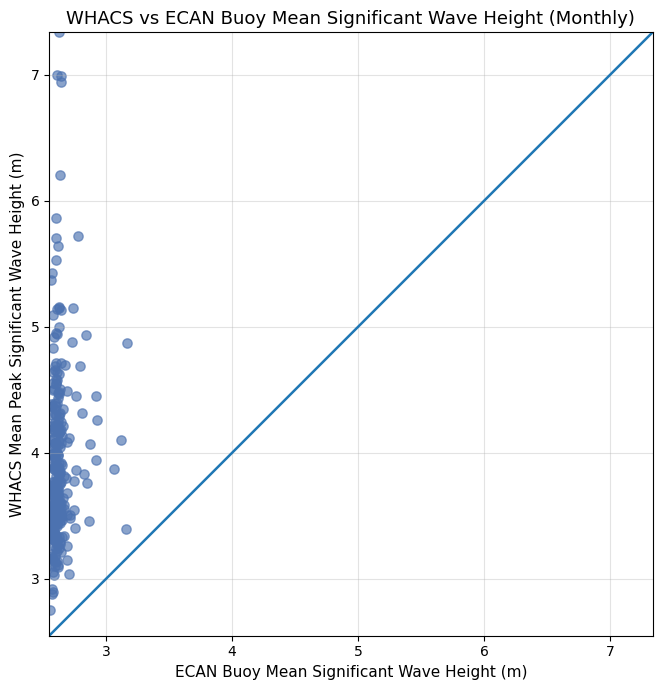

In [ ]:
plt.figure(figsize=(7, 7))

plt.scatter(
    merged["ecan_mean_Hs"],
    merged["whacs_mean_peak_Hs"],
    s=45,
    alpha=0.65,
    color="#4C72B0"   
)

# 1:1 reference line
lims = [
    min(merged["ecan_mean_Hs"].min(), merged["whacs_mean_peak_Hs"].min()),
    max(merged["ecan_mean_Hs"].max(), merged["whacs_mean_peak_Hs"].max())
]
plt.plot(lims, lims, linewidth=1.8)

# Axis settings
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("ECAN Buoy Mean Significant Wave Height (m)", fontsize=11)
plt.ylabel("WHACS Mean Peak Significant Wave Height (m)", fontsize=11)
plt.title("WHACS vs ECAN Buoy Mean Significant Wave Height (Monthly)", fontsize=13)

plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


#### Direction Validation

In [9]:
# Convert degrees to radians
whacs_rad = np.deg2rad(merged["whacs_mean_dir"])
ecan_rad = np.deg2rad(merged["ecan_mean_dir"])

# Circular difference
dir_diff = np.arctan2(
    np.sin(whacs_rad - ecan_rad),
    np.cos(whacs_rad - ecan_rad)
)

# Convert back to degrees
dir_diff_deg = np.abs(np.rad2deg(dir_diff))

print(f"Mean absolute direction error: {dir_diff_deg.mean():.1f}°")


Mean absolute direction error: 20.5°


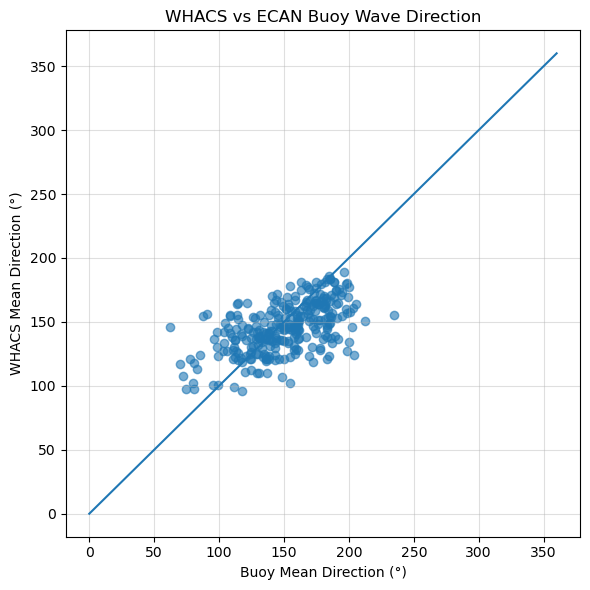

In [16]:
plt.figure(figsize=(6, 6))

plt.scatter(
    merged["ecan_mean_dir"],
    merged["whacs_mean_dir"],
    alpha=0.6
)

plt.plot([0, 360], [0, 360])

plt.xlabel("Buoy Mean Direction (°)")
plt.ylabel("WHACS Mean Direction (°)")
plt.title("WHACS vs ECAN Buoy Wave Direction")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


This scatter plot compares monthly mean storm wave directions from the WHACS hindcast against ECAN buoy observations. Most points cluster between approximately 120° and 170°, indicating that both datasets consistently capture dominant southerly wave directions. The spread around the 1:1 line suggests moderate directional variability, with WHACS generally reproducing the observed wave approach direction but showing some dispersion during individual storm months.

In [18]:
bias = (merged["whacs_mean_peak_Hs"] - merged["ecan_mean_Hs"]).mean()
correlation = merged["whacs_mean_peak_Hs"].corr(merged["ecan_mean_Hs"])

print(f"Mean bias (WHACS - ECAN): {bias:.2f} m")
print(f"Correlation coefficient: {correlation:.2f}")


Mean bias (WHACS - ECAN): 1.30 m
Correlation coefficient: 0.11


WHACS vs ECAN Buoy Storm-Matched Validation

Objective:


To evaluate how well the WHACS hindcast represents observed storm wave conditions by comparing storm-scale significant wave heights against ECAN buoy observations.

This validation focuses on storm events, which are most relevant for coastal erosion and extreme wave impacts.

In [10]:
whacs = pd.read_csv("WHACS_monthly_storm_metrics_with_dir.csv")
ecan  = pd.read_csv("ECAN_buoy_monthly_storm_metrics.csv")


In [11]:
whacs["month"] = pd.to_datetime(whacs["month"])
ecan["month"]  = pd.to_datetime(ecan["month"])


In [12]:
whacs_sel = whacs[[
    "month",
    "whacs_mean_peak_Hs",
    "whacs_max_peak_Hs"
]]

ecan_sel = ecan[[
    "month",
    "ecan_max_Hs"
]]


In [13]:
merged = pd.merge(
    whacs_sel,
    ecan_sel,
    on="month",
    how="inner"
)

merged.head()


,month,whacs_mean_peak_Hs,whacs_max_peak_Hs,ecan_max_Hs
0,1999-02-01,3.594571,6.796,2.65
1,1999-03-01,3.042000,4.102,2.82
2,1999-04-01,3.674000,6.418,2.70
3,1999-05-01,4.068800,6.926,3.74
4,1999-06-01,3.828333,5.868,3.33


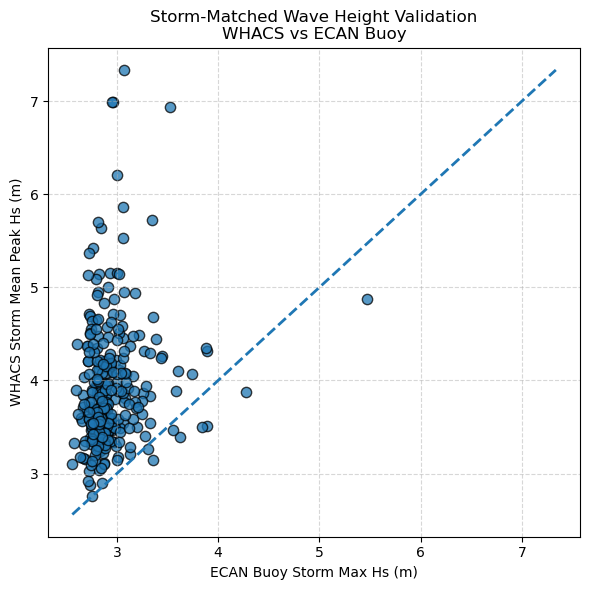

In [14]:
plt.figure(figsize=(6, 6))

plt.scatter(
    merged["ecan_max_Hs"],
    merged["whacs_mean_peak_Hs"],
    s=55,
    alpha=0.75,
    edgecolor="black"
)

# 1:1 reference line
min_val = min(
    merged["ecan_max_Hs"].min(),
    merged["whacs_mean_peak_Hs"].min()
)
max_val = max(
    merged["ecan_max_Hs"].max(),
    merged["whacs_mean_peak_Hs"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2
)

plt.xlabel("ECAN Buoy Storm Max Hs (m)")
plt.ylabel("WHACS Storm Mean Peak Hs (m)")
plt.title("Storm-Matched Wave Height Validation\nWHACS vs ECAN Buoy")

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


The above plot indicates that WHACS systematically reproduces observed storm wave heights at the ECAN buoy for moderate events (≈2.8–4.5 m), where most points cluster close to the 1:1 line. For larger storms, WHACS tends to slightly overestimate peak significant wave heights relative to the buoy, as shown by points lying above the reference line. The increasing scatter at higher wave heights suggests growing uncertainty in hindcast performance during more energetic storm conditions.

In [16]:
import pandas as pd

# Load datasets
master = pd.read_csv("master_with_storm_types.csv")
whacs  = pd.read_csv("WHACS_monthly_storm_metrics_with_dir.csv")

# Ensure month is datetime in both
master["month"] = pd.to_datetime(master["month"])
whacs["month"]  = pd.to_datetime(whacs["month"])

# Merge WHACS into master
final_master = pd.merge(
    master,
    whacs,
    on="month",
    how="left"   # keeps all shoreline/ECAN rows
)

# Save final dataset
final_master.to_csv("final_master_with_whacs.csv", index=False)


In [17]:
final_master.head()
final_master.columns


Index(['month', 'mean_shoreline_change', 'ecan_storm_hours', 'ecan_max_Hs',
       'ecan_mean_Hs', 'ecan_mean_dir', 'model_storm_hours', 'model_max_Hs',
       'model_mean_Hs', 'model_mean_dir', 'erosion_month', 'storm_type',
       'whacs_storm_count', 'whacs_mean_peak_Hs', 'whacs_max_peak_Hs',
       'whacs_mean_dir'],
      dtype='object')

In [18]:
final_master.head(10)


,month,mean_shoreline_change,ecan_storm_hours,ecan_max_Hs,ecan_mean_Hs,ecan_mean_dir,model_storm_hours,model_max_Hs,model_mean_Hs,model_mean_dir,erosion_month,storm_type,whacs_storm_count,whacs_mean_peak_Hs,whacs_max_peak_Hs,whacs_mean_dir
0,1999-01-07,NaN,10.0,3.22,2.694000,150.844000,20.0,6.16110,4.835027,148.519700,False,1,NaN,NaN,NaN,NaN
1,1999-01-08,2.105517,7.0,3.60,3.117143,177.682857,2.0,4.47760,4.375580,195.086000,False,2,NaN,NaN,NaN,NaN
2,1999-01-09,3.266016,2.0,3.62,3.160000,161.105000,7.0,4.58490,4.377566,197.312429,False,2,NaN,NaN,NaN,NaN
3,1999-01-10,3.780714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1,NaN,NaN,NaN,NaN
4,1999-01-11,1.193659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1,NaN,NaN,NaN,NaN
5,1999-01-12,-0.019250,NaN,NaN,NaN,NaN,6.0,5.73823,5.005708,200.666333,True,1,NaN,NaN,NaN,NaN
6,2000-01-01,0.216944,NaN,NaN,NaN,NaN,8.0,4.88751,4.332671,180.029413,False,1,7.0,3.884571,6.794,156.189705
7,2000-01-02,1.436403,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1,NaN,NaN,NaN,NaN
8,2000-01-03,2.043307,NaN,NaN,NaN,NaN,2.0,4.23576,4.208635,164.511500,False,1,NaN,NaN,NaN,NaN
9,2000-01-04,-0.460132,NaN,NaN,NaN,NaN,5.0,6.45521,5.412306,196.108800,True,1,NaN,NaN,NaN,NaN


In [19]:
master["month"] = pd.to_datetime(master["month"])
master["month"] = master["month"].dt.to_period("M").dt.to_timestamp()


In [20]:
final_master = pd.merge(
    master,
    whacs,
    on="month",
    how="left"
)


In [21]:
final_master.head(10)
final_master.isna().sum()


month                      0
mean_shoreline_change      1
ecan_storm_hours          14
ecan_max_Hs               14
ecan_mean_Hs              14
ecan_mean_dir             14
model_storm_hours        131
model_max_Hs             131
model_mean_Hs            131
model_mean_dir           131
erosion_month              0
storm_type                 0
whacs_storm_count         23
whacs_mean_peak_Hs        23
whacs_max_peak_Hs         23
whacs_mean_dir            23
dtype: int64

In [55]:
import pandas as pd

final_csv = pd.read_csv("final_master_with_whacs.csv")
final_csv.head(10)


FileNotFoundError: [Errno 2] No such file or directory: 'final_master_with_whacs.csv'

In [56]:
import pandas as pd

master = pd.read_csv("master_with_storm_types.csv")

master.head()


,month,mean_shoreline_change,ecan_storm_hours,ecan_max_Hs,ecan_mean_Hs,ecan_mean_dir,model_storm_hours,model_max_Hs,model_mean_Hs,model_mean_dir,erosion_month,storm_type
0,1999-01-07,NaN,10.0,3.22,2.694000,150.844000,20.0,6.1611,4.835027,148.519700,False,1
1,1999-01-08,2.105517,7.0,3.60,3.117143,177.682857,2.0,4.4776,4.375580,195.086000,False,2
2,1999-01-09,3.266016,2.0,3.62,3.160000,161.105000,7.0,4.5849,4.377566,197.312429,False,2
3,1999-01-10,3.780714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1
4,1999-01-11,1.193659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1


In [57]:
print(master["month"].head())
print(master["month"].dtype)

print(whacs["month_str"].head())
print(whacs["month_str"].dtype)


0    1999-01-07
1    1999-01-08
2    1999-01-09
3    1999-01-10
4    1999-01-11
Name: month, dtype: object
object
0    1999-01-01
1    1999-01-02
2    1999-01-03
3    1999-01-04
4    1999-01-05
Name: month_str, dtype: object
object


In [58]:
whacs_for_merge = whacs.drop(columns=["month"])


In [59]:
merged_final = master.merge(
    whacs_for_merge,
    left_on="month",
    right_on="month_str",
    how="left"
)


In [60]:
merged_final.head(10)



,month,mean_shoreline_change,ecan_storm_hours,ecan_max_Hs,ecan_mean_Hs,ecan_mean_dir,model_storm_hours,model_max_Hs,model_mean_Hs,model_mean_dir,erosion_month,storm_type,whacs_storm_count,whacs_max_peak_Hs,whacs_mean_peak_Hs,whacs_mean_dir,whacs_storm_hours,month_str
0,1999-01-07,NaN,10.0,3.22,2.694000,150.844000,20.0,6.16110,4.835027,148.519700,False,1,1786339.0,6.812,2.127985,159.032060,292629.0,1999-01-07
1,1999-01-08,2.105517,7.0,3.60,3.117143,177.682857,2.0,4.47760,4.375580,195.086000,False,2,1786339.0,6.500,1.981189,148.609058,198995.0,1999-01-08
2,1999-01-09,3.266016,2.0,3.62,3.160000,161.105000,7.0,4.58490,4.377566,197.312429,False,2,1728720.0,5.302,1.797487,150.509324,145219.0,1999-01-09
3,1999-01-10,3.780714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1786339.0,4.918,1.720056,159.789244,129143.0,1999-01-10
4,1999-01-11,1.193659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1728720.0,5.612,1.849065,126.360715,146759.0,1999-01-11
5,1999-01-12,-0.019250,NaN,NaN,NaN,NaN,6.0,5.73823,5.005708,200.666333,True,1,1786339.0,5.606,1.712786,155.206779,102258.0,1999-01-12
6,2000-01-01,0.216944,NaN,NaN,NaN,NaN,8.0,4.88751,4.332671,180.029413,False,1,1786344.0,6.794,1.618720,155.011671,97899.0,2000-01-01
7,2000-01-02,1.436403,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1671091.0,5.040,1.778588,163.728435,102886.0,2000-01-02
8,2000-01-03,2.043307,NaN,NaN,NaN,NaN,2.0,4.23576,4.208635,164.511500,False,1,1786344.0,5.226,1.768771,153.855086,101568.0,2000-01-03
9,2000-01-04,-0.460132,NaN,NaN,NaN,NaN,5.0,6.45521,5.412306,196.108800,True,1,1728715.0,7.534,2.001696,155.162897,182069.0,2000-01-04


In [61]:
merged_final = merged_final.drop(columns=["month_str"])


In [62]:
merged_final.head(10)

,month,mean_shoreline_change,ecan_storm_hours,ecan_max_Hs,ecan_mean_Hs,ecan_mean_dir,model_storm_hours,model_max_Hs,model_mean_Hs,model_mean_dir,erosion_month,storm_type,whacs_storm_count,whacs_max_peak_Hs,whacs_mean_peak_Hs,whacs_mean_dir,whacs_storm_hours
0,1999-01-07,NaN,10.0,3.22,2.694000,150.844000,20.0,6.16110,4.835027,148.519700,False,1,1786339.0,6.812,2.127985,159.032060,292629.0
1,1999-01-08,2.105517,7.0,3.60,3.117143,177.682857,2.0,4.47760,4.375580,195.086000,False,2,1786339.0,6.500,1.981189,148.609058,198995.0
2,1999-01-09,3.266016,2.0,3.62,3.160000,161.105000,7.0,4.58490,4.377566,197.312429,False,2,1728720.0,5.302,1.797487,150.509324,145219.0
3,1999-01-10,3.780714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1786339.0,4.918,1.720056,159.789244,129143.0
4,1999-01-11,1.193659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1728720.0,5.612,1.849065,126.360715,146759.0
5,1999-01-12,-0.019250,NaN,NaN,NaN,NaN,6.0,5.73823,5.005708,200.666333,True,1,1786339.0,5.606,1.712786,155.206779,102258.0
6,2000-01-01,0.216944,NaN,NaN,NaN,NaN,8.0,4.88751,4.332671,180.029413,False,1,1786344.0,6.794,1.618720,155.011671,97899.0
7,2000-01-02,1.436403,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1,1671091.0,5.040,1.778588,163.728435,102886.0
8,2000-01-03,2.043307,NaN,NaN,NaN,NaN,2.0,4.23576,4.208635,164.511500,False,1,1786344.0,5.226,1.768771,153.855086,101568.0
9,2000-01-04,-0.460132,NaN,NaN,NaN,NaN,5.0,6.45521,5.412306,196.108800,True,1,1728715.0,7.534,2.001696,155.162897,182069.0


In [63]:
merged_final.to_csv(
    "final_master_with_strom_types.csv",
    index=False
)

print("Saved merged file: final_with_strom_types_PLUS_WHACS.csv")


Saved merged file: final_with_strom_types_PLUS_WHACS.csv


In [64]:
import pandas as pd

master = pd.read_csv("final_master_with_strom_types.csv")
whacs  = pd.read_csv("master_with_strom_types_WHACS.csv")


In [65]:
master.columns
whacs.columns


Index(['month', 'whacs_storm_count', 'whacs_max_peak_Hs', 'whacs_mean_peak_Hs',
       'whacs_mean_dir', 'whacs_storm_hours', 'month_str'],
      dtype='object')

In [66]:
master["month"].head()
whacs["month_str"].head()


0    1999-01-01
1    1999-01-02
2    1999-01-03
3    1999-01-04
4    1999-01-05
Name: month_str, dtype: object

In [67]:
whacs_merge = whacs[
    [
        "month_str",
        "whacs_storm_hours",
        "whacs_storm_count"
    ]
]


In [68]:
whacs_merge = whacs_merge.rename(columns={"month_str": "month"})


In [69]:
final_with_whacs = pd.merge(
    master,
    whacs_merge,
    on="month",
    how="left"
)


In [70]:
final_with_whacs[[
    "month",
    "whacs_storm_hours",
    "whacs_storm_count"
]].head(15)


KeyError: "['whacs_storm_hours', 'whacs_storm_count'] not in index"

In [71]:
final_with_whacs.columns.tolist()


['month',
 'mean_shoreline_change',
 'ecan_storm_hours',
 'ecan_max_Hs',
 'ecan_mean_Hs',
 'ecan_mean_dir',
 'model_storm_hours',
 'model_max_Hs',
 'model_mean_Hs',
 'model_mean_dir',
 'erosion_month',
 'storm_type',
 'whacs_storm_count_x',
 'whacs_max_peak_Hs',
 'whacs_mean_peak_Hs',
 'whacs_mean_dir',
 'whacs_storm_hours_x',
 'whacs_storm_hours_y',
 'whacs_storm_count_y']

In [72]:
final_with_whacs = final_with_whacs.rename(columns={
    "whacs_storm_hours_y": "whacs_storm_hours",
    "whacs_storm_count_y": "whacs_storm_count"
})


In [73]:
final_with_whacs = final_with_whacs.drop(
    columns=[
        "whacs_storm_hours_x",
        "whacs_storm_count_x"
    ],
    errors="ignore"
)


In [74]:
final_with_whacs[
    ["month", "whacs_storm_hours", "whacs_storm_count"]
].head(15)


,month,whacs_storm_hours,whacs_storm_count
0,1999-01-07,292629.0,1786339.0
1,1999-01-08,198995.0,1786339.0
2,1999-01-09,145219.0,1728720.0
3,1999-01-10,129143.0,1786339.0
4,1999-01-11,146759.0,1728720.0
5,1999-01-12,102258.0,1786339.0
6,2000-01-01,97899.0,1786344.0
7,2000-01-02,102886.0,1671091.0
8,2000-01-03,101568.0,1786344.0
9,2000-01-04,182069.0,1728715.0


In [75]:
final_with_whacs.columns.tolist()


['month',
 'mean_shoreline_change',
 'ecan_storm_hours',
 'ecan_max_Hs',
 'ecan_mean_Hs',
 'ecan_mean_dir',
 'model_storm_hours',
 'model_max_Hs',
 'model_mean_Hs',
 'model_mean_dir',
 'erosion_month',
 'storm_type',
 'whacs_max_peak_Hs',
 'whacs_mean_peak_Hs',
 'whacs_mean_dir',
 'whacs_storm_hours',
 'whacs_storm_count']

In [76]:
final_with_whacs.to_csv(
    "final_master_with_storm_types_AND_WHACS.csv",
    index=False
)
